In [1]:
from resources.imports import *
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torchinfo import summary

import optuna 
import networkx as nx

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, GCN, GAT

# GNN Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="GNN")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")     

Using device: cpu


In [25]:
perIN_ = DAT.perIN.reshape(int(len(DAT.perIN)/2), 2)
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [26]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [8, 32, 128]

BATCH_SIZE = 8
LEARNING_RATE = 1e-3

In [27]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.train_in, DAT.train_outST)]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.val_in, DAT.val_outST)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.test_in, DAT.test_outST)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

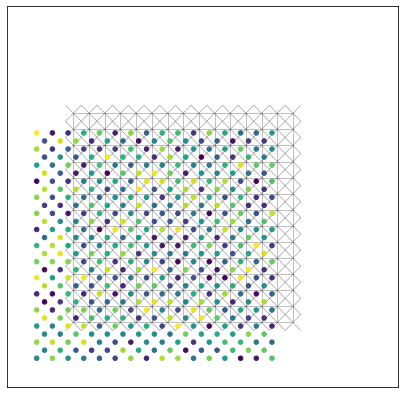

In [28]:
visualize_graphNetwork(train_dataloader, pos=perIN_, colors=None, layout="kk")

In [33]:
GCN1 = MODEL(
    typ="GNN",
    model=GCN(in_size, h_size, out_size, norm="layer", pool="mean").to(device),
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 8, 1e-4, True), 
    earlyStop=EarlyStopping(patience=25, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

GAT1 = MODEL(
    typ="GNN",
    model=GAT(in_size, h_size, out_size, heads=2, norm="layer", pool="mean").to(device),
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 8, 1e-4, True), 
    earlyStop=EarlyStopping(patience=25, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

# summary(GAT1.model, input_size=(BATCH_SIZE, in_size))

Epoch: 1 - Loss: 0.00394729757681489
Early stopping triggered after 25 epochs without improvement.
Best Epoch: 6, with loss 0.0018395737279206514


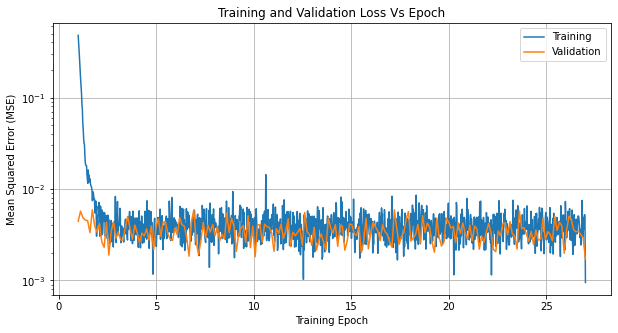

In [34]:
GAT1.train(n_epochs=500, verbose=50, plot=True)

Best prediction: 135, Worst prediction: 62


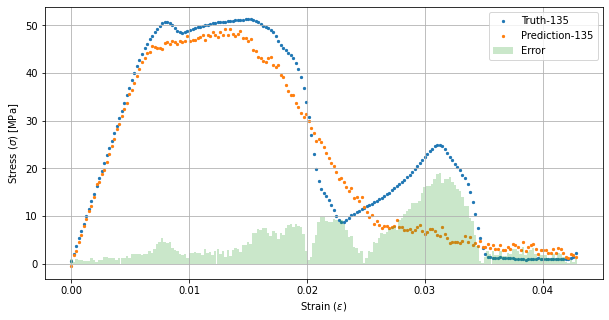

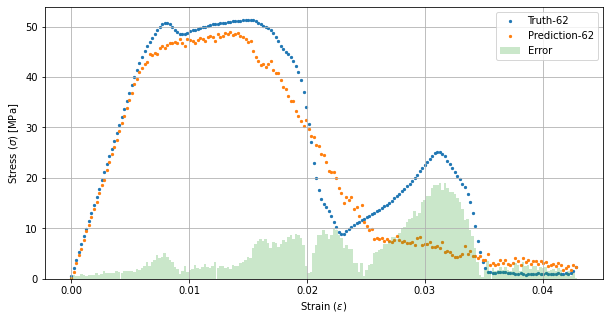

In [35]:
GAT1.predict(stand=True, plot=True)